In [29]:
import pandas as pd
import numpy as np
from utils import plot

In [30]:
df = pd.read_csv('wbtc_train_data_expanded.csv')

nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

df_amounts = pd.read_csv('wbtc_token_amounts_data.csv')
total_supply = df_amounts['island_token_balance'].values
stable_token_balance = df_amounts['honey_balance'].values
vol_token_balance = df_amounts['wbtc_balance'].values

total_supply = total_supply[len(vol_token_balance) - len(vol_token_price):]
stable_token_balance = stable_token_balance[len(vol_token_balance) - len(vol_token_price):]
vol_token_balance = vol_token_balance[len(vol_token_balance) - len(vol_token_price):]

6.096488553396355e-06 0.0004868141613705003
-2.20949784582445e-06 0.002859470286952047
-1.2410384025896776e-05 0.002641502701385392
-6.272759016659789e-06 0.001851549810493781


c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


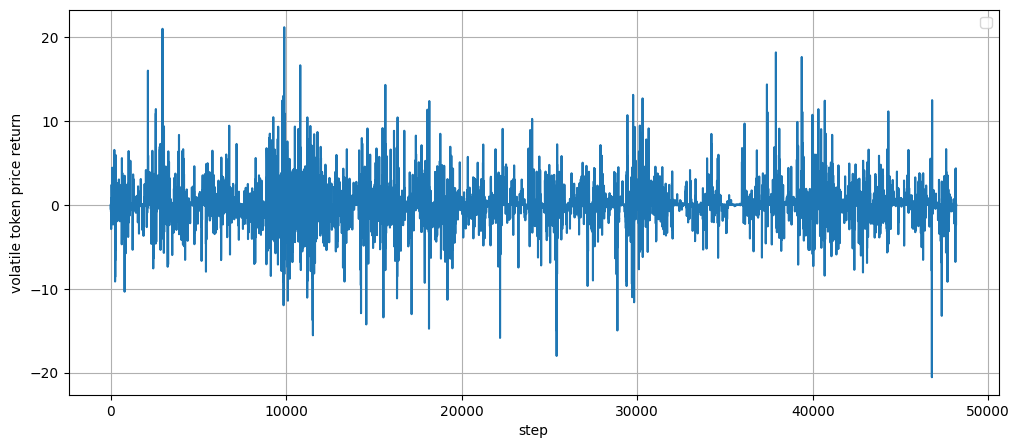

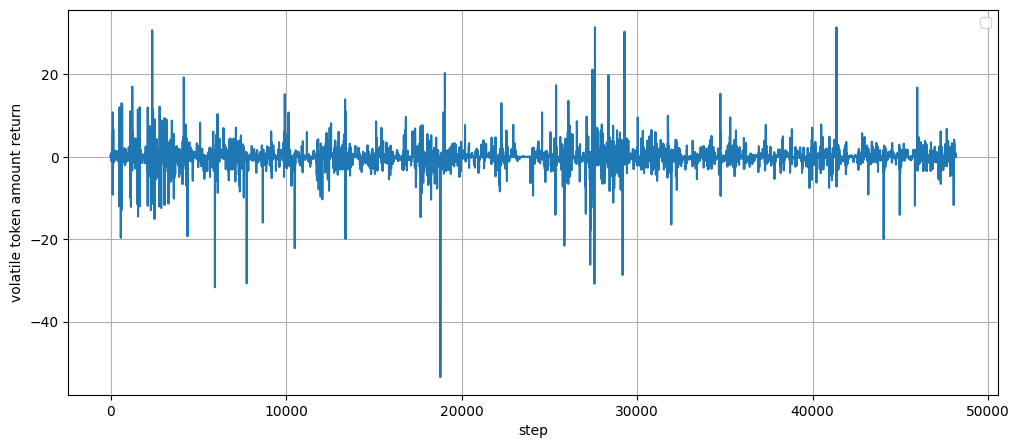

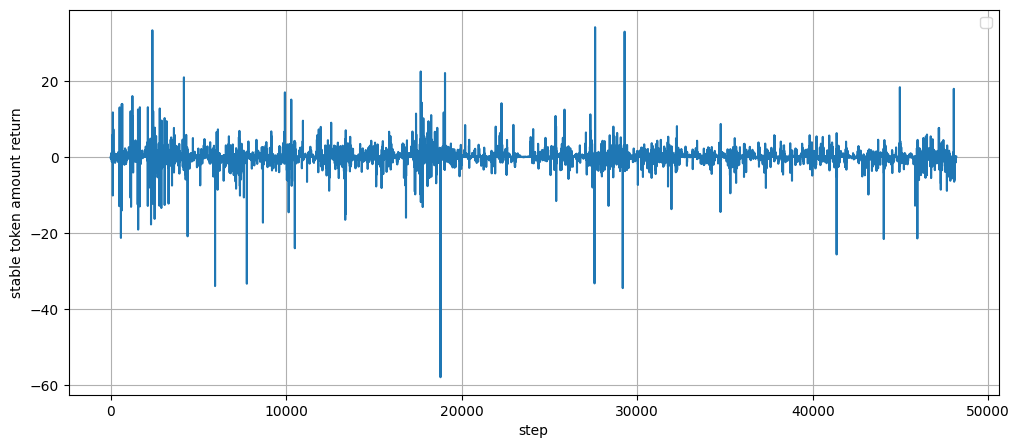

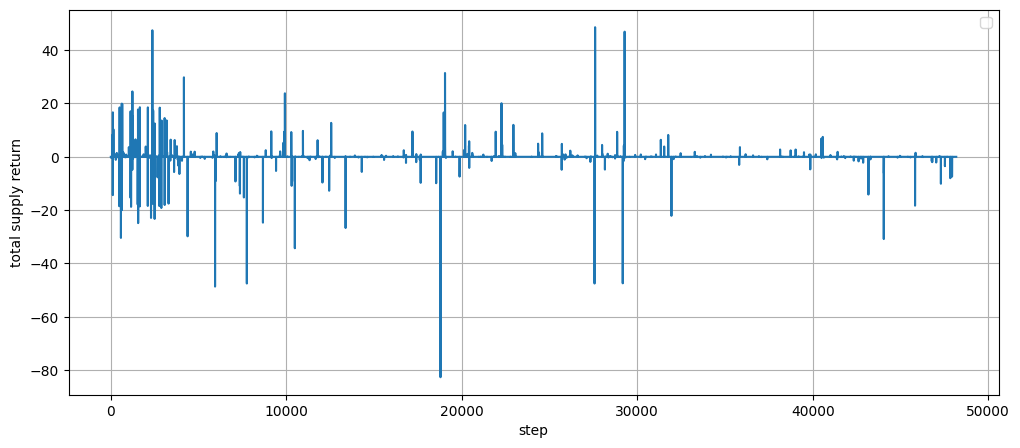

In [31]:
p_r = np.diff(np.log(vol_token_price))
v_r = np.diff(np.log(vol_token_balance))
s_r = np.diff(np.log(stable_token_balance))
ts_r = np.diff(np.log(total_supply))

print(np.mean(p_r), np.std(p_r))
print(np.mean(v_r), np.std(v_r))
print(np.mean(s_r), np.std(s_r))
print(np.mean(ts_r), np.std(ts_r))

p_r_normed = p_r/np.std(p_r)
v_r_normed = v_r/np.std(v_r)
s_r_normed = s_r/np.std(s_r)
ts_r_normed = ts_r/np.std(ts_r)

plot(
    [p_r_normed],
    'step',
    'volatile token price return'
)

plot(
    [v_r_normed],
    'step',
    'volatile token amount return'
)

plot(
    [s_r_normed],
    'step',
    'stable token amount return'
)

plot(
    [ts_r_normed],
    'step',
    'total supply return'
)

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


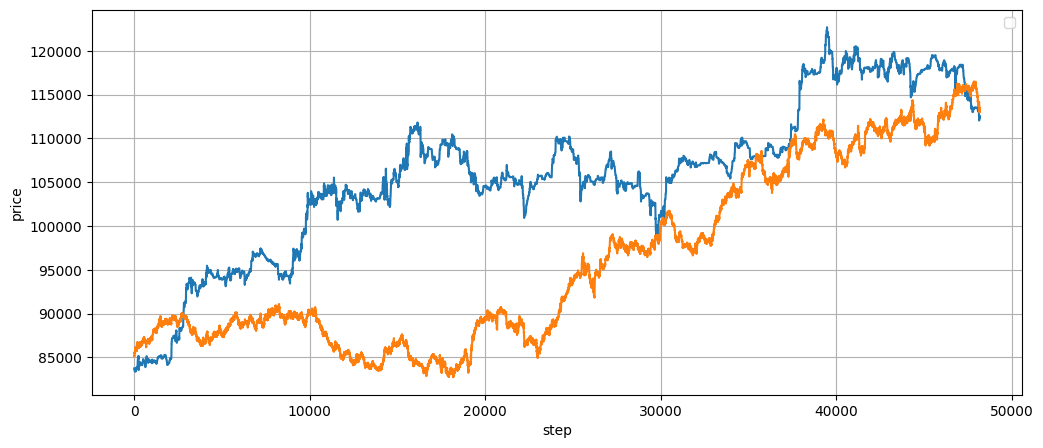

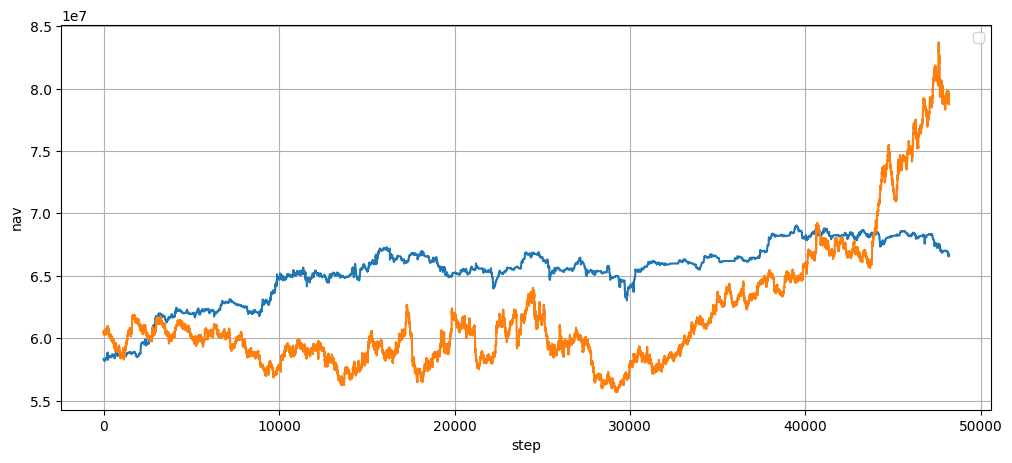

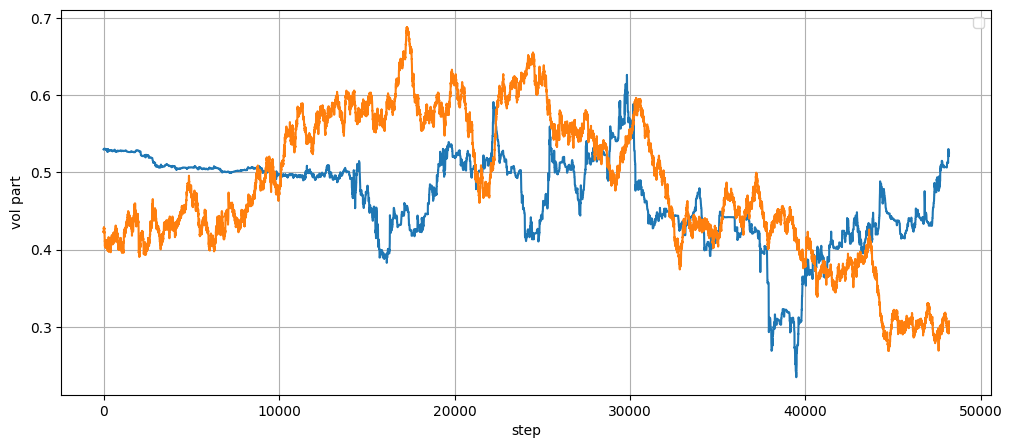

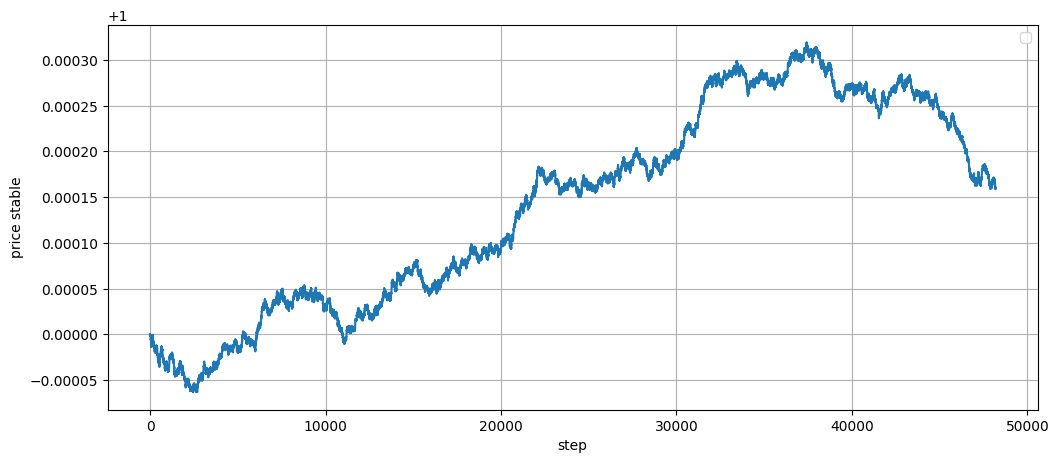

In [32]:
from data_generator_v2 import simulate_data

p_test, nav_test, vol_part_test, p_stable = simulate_data(len(nav))

plot(
    [vol_token_price, p_test],
    'step',
    'price'
)

plot(
    [nav, nav_test],
    'step',
    'nav'
)

plot(
    [volatile_part, vol_part_test],
    'step',
    'vol part'
)

plot(
    [p_stable],
    'step',
    'price stable'
)
